In [2]:
img_path = "/Users/shreyagupta/Desktop/img_align_celeba/000086.jpg"
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


Loaded image with shape: (218, 178, 3)


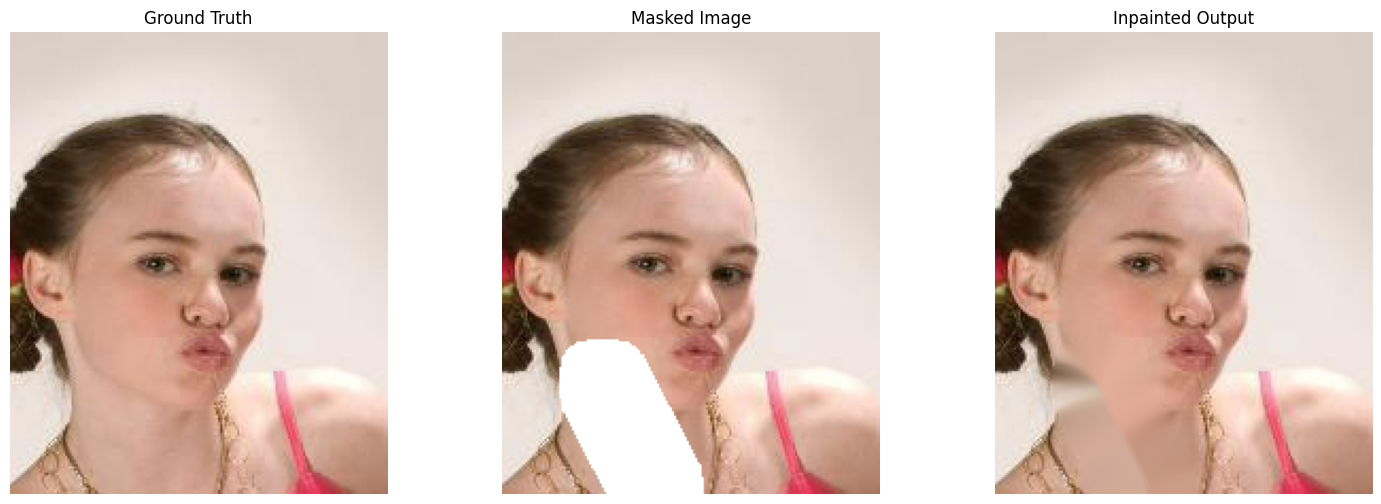

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# Step 1: Load the image
# ==============================
# Change this path to match where your image is stored
img_path = "/Users/shreyagupta/Desktop/img_align_celeba/000086.jpg"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found at: {img_path}")

# OpenCV loads images as BGR, so convert to RGB
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape
print(f"Loaded image with shape: {image.shape}")

# ==============================
# Step 2: Generate irregular mask
# ==============================
def generate_irregular_mask(height, width, max_strokes=8):
    mask = np.zeros((height, width), dtype=np.uint8)
    for _ in range(np.random.randint(1, max_strokes)):
        x1, y1 = np.random.randint(0, width), np.random.randint(0, height)
        x2, y2 = np.random.randint(0, width), np.random.randint(0, height)
        thickness = np.random.randint(15, 50)
        cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)
    # Dilate strokes to make holes bigger
    mask = cv2.dilate(mask, np.ones((15,15), np.uint8), iterations=1)
    return mask

mask = generate_irregular_mask(h, w)

# ==============================
# Step 3: Apply mask to image
# ==============================
masked_img = image.copy()
masked_img[mask==255] = 255  # white-out masked regions

# ==============================
# Step 4: Inpainting (OpenCV demo)
# ==============================
# Options: cv2.INPAINT_TELEA or cv2.INPAINT_NS
inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

# ==============================
# Step 5: Display results
# ==============================
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img)
plt.title("Masked Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(inpainted)
plt.title("Inpainted Output")
plt.axis("off")

plt.show()


Loaded image with shape: (218, 178, 3)


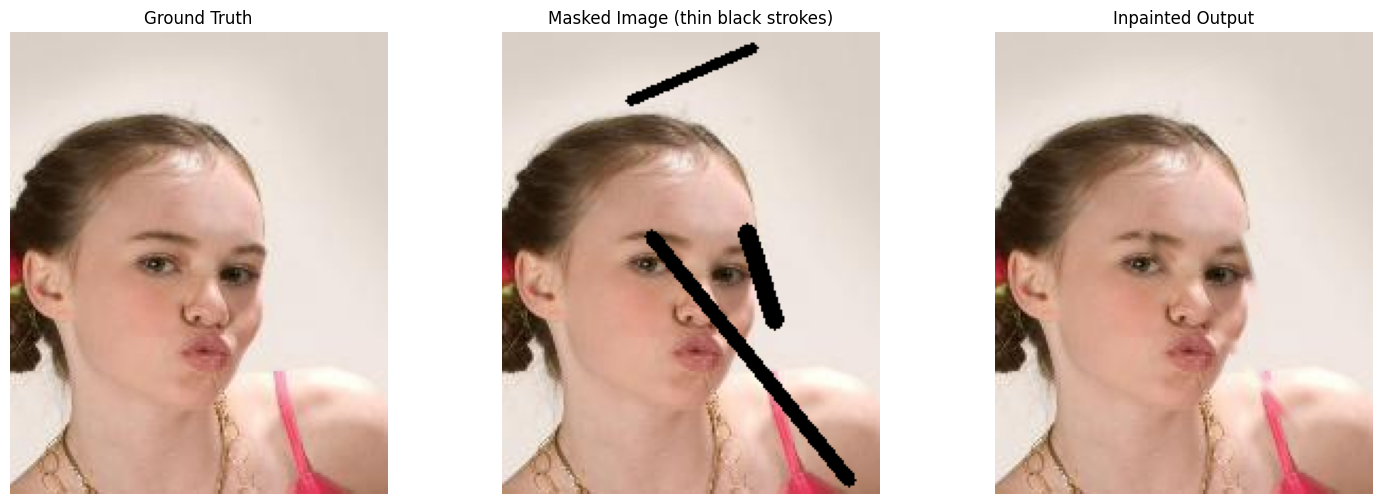

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# Step 1: Load the image
# ==============================
img_path = "/Users/shreyagupta/Desktop/img_align_celeba/000086.jpg"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found at: {img_path}")

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape
print(f"Loaded image with shape: {image.shape}")

# ==============================
# Step 2: Generate irregular mask (2–3 thin strokes)
# ==============================
def generate_irregular_mask(height, width, min_strokes=2, max_strokes=3):
    mask = np.zeros((height, width), dtype=np.uint8)
    num_strokes = np.random.randint(min_strokes, max_strokes+1)
    for _ in range(num_strokes):
        x1, y1 = np.random.randint(0, width), np.random.randint(0, height)
        x2, y2 = np.random.randint(0, width), np.random.randint(0, height)
        thickness = np.random.randint(3, 10)  # thin lines
        cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)
    return mask

mask = generate_irregular_mask(h, w)

# ==============================
# Step 3: Apply mask to image (black-out regions)
# ==============================
masked_img = image.copy()
masked_img[mask==255] = 0  # black-out masked regions

# ==============================
# Step 4: Inpainting (OpenCV demo)
# ==============================
inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

# ==============================
# Step 5: Display results
# ==============================
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img)
plt.title("Masked Image (thin black strokes)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(inpainted)
plt.title("Inpainted Output")
plt.axis("off")

plt.show()


In [8]:
!pip install scikit-image


In [10]:
!pip install scikit-image


Loaded image with shape: (218, 178, 3)


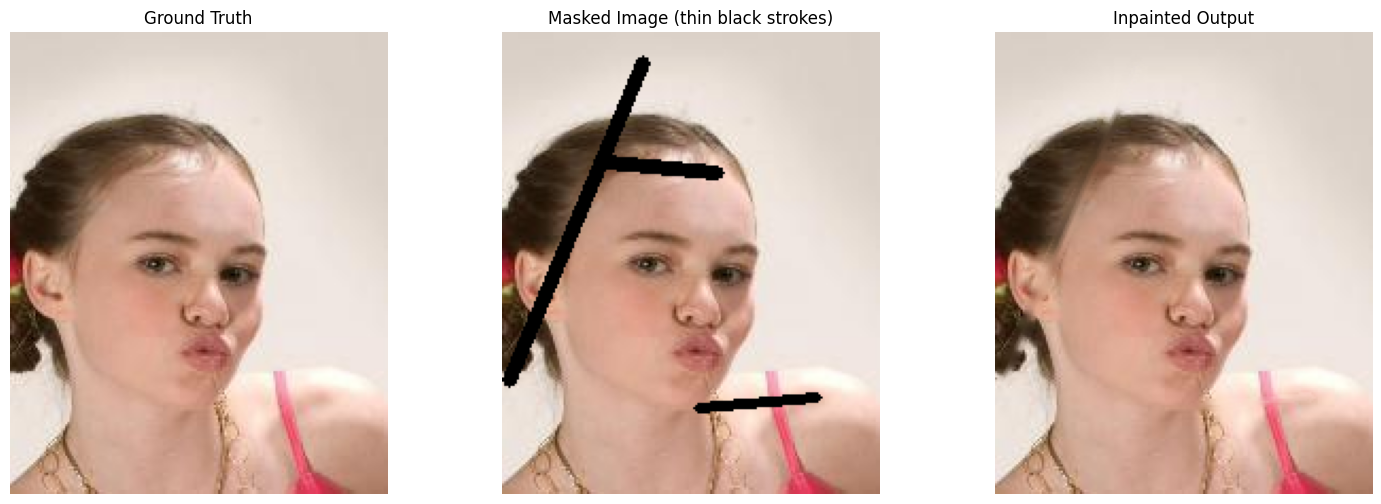

PSNR: 35.99 dB
SSIM: 0.9850


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# Step 1: Load the image
# ==============================
img_path = "/Users/shreyagupta/Desktop/img_align_celeba/000086.jpg"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found at: {img_path}")

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w, _ = image.shape
print(f"Loaded image with shape: {image.shape}")

# ==============================
# Step 2: Generate irregular mask (2–3 thin strokes)
# ==============================
def generate_irregular_mask(height, width, min_strokes=2, max_strokes=3):
    mask = np.zeros((height, width), dtype=np.uint8)
    num_strokes = np.random.randint(min_strokes, max_strokes+1)
    for _ in range(num_strokes):
        x1, y1 = np.random.randint(0, width), np.random.randint(0, height)
        x2, y2 = np.random.randint(0, width), np.random.randint(0, height)
        thickness = np.random.randint(3, 10)  # thin lines
        cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)
    return mask

mask = generate_irregular_mask(h, w)

# ==============================
# Step 3: Apply mask to image (black-out regions)
# ==============================
masked_img = image.copy()
masked_img[mask==255] = 0

# ==============================
# Step 4: Inpainting (OpenCV demo)
# ==============================
inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

# ==============================
# Step 5: Display results
# ==============================
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img)
plt.title("Masked Image (thin black strokes)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(inpainted)
plt.title("Inpainted Output")
plt.axis("off")

plt.show()

# ==============================
# Step 6: PSNR & SSIM (manual SSIM implementation)
# ==============================
def compute_ssim(img1, img2):
    """Compute SSIM for two RGB images (manual version, no skimage)."""
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    K1, K2 = 0.01, 0.03
    L = 255
    C1 = (K1 * L) ** 2
    C2 = (K2 * L) ** 2

    ssim_total = 0
    for ch in range(3):  # per-channel SSIM
        x = img1[:,:,ch]
        y = img2[:,:,ch]

        mu_x = cv2.GaussianBlur(x, (11,11), 1.5)
        mu_y = cv2.GaussianBlur(y, (11,11), 1.5)

        mu_x_sq = mu_x * mu_x
        mu_y_sq = mu_y * mu_y
        mu_xy = mu_x * mu_y

        sigma_x_sq = cv2.GaussianBlur(x*x, (11,11), 1.5) - mu_x_sq
        sigma_y_sq = cv2.GaussianBlur(y*y, (11,11), 1.5) - mu_y_sq
        sigma_xy   = cv2.GaussianBlur(x*y, (11,11), 1.5) - mu_xy

        ssim_map = ((2*mu_xy + C1) * (2*sigma_xy + C2)) / \
                   ((mu_x_sq + mu_y_sq + C1) * (sigma_x_sq + sigma_y_sq + C2))

        ssim_total += ssim_map.mean()

    return ssim_total / 3

# Compute metrics
psnr_value = cv2.PSNR(image, inpainted)
ssim_value = compute_ssim(image, inpainted)

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.4f}")


Loaded image with shape: (64, 64, 3)


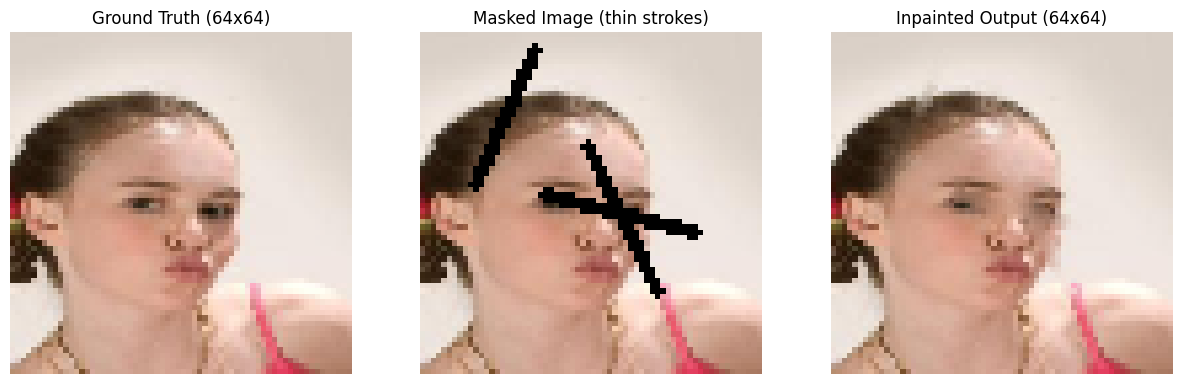

PSNR: 32.14 dB
SSIM: 0.9826


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# Step 1: Load and resize image
# ==============================
img_path = "/Users/shreyagupta/Desktop/img_align_celeba/000086.jpg"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found at: {img_path}")

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (64, 64))   # resize to 64x64
h, w, _ = image.shape
print(f"Loaded image with shape: {image.shape}")

# ==============================
# Step 2: Generate irregular mask (2–3 thin strokes)
# ==============================
def generate_irregular_mask(height, width, min_strokes=2, max_strokes=3):
    mask = np.zeros((height, width), dtype=np.uint8)
    num_strokes = np.random.randint(min_strokes, max_strokes+1)
    for _ in range(num_strokes):
        x1, y1 = np.random.randint(0, width), np.random.randint(0, height)
        x2, y2 = np.random.randint(0, width), np.random.randint(0, height)
        thickness = np.random.randint(1, 3)  # very thin lines
        cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)
    return mask

mask = generate_irregular_mask(h, w)

# ==============================
# Step 3: Apply mask to image (black-out regions)
# ==============================
masked_img = image.copy()
masked_img[mask==255] = 0

# ==============================
# Step 4: Inpainting (OpenCV demo)
# ==============================
inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

# ==============================
# Step 5: Display results
# ==============================
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Ground Truth (64x64)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img)
plt.title("Masked Image (thin strokes)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(inpainted)
plt.title("Inpainted Output (64x64)")
plt.axis("off")

plt.show()

# ==============================
# Step 6: PSNR & SSIM
# ==============================
def compute_ssim(img1, img2):
    """Compute SSIM for two RGB images (manual version, no skimage)."""
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    K1, K2 = 0.01, 0.03
    L = 255
    C1 = (K1 * L) ** 2
    C2 = (K2 * L) ** 2

    ssim_total = 0
    for ch in range(3):  # per-channel SSIM
        x = img1[:,:,ch]
        y = img2[:,:,ch]

        mu_x = cv2.GaussianBlur(x, (11,11), 1.5)
        mu_y = cv2.GaussianBlur(y, (11,11), 1.5)

        mu_x_sq = mu_x * mu_x
        mu_y_sq = mu_y * mu_y
        mu_xy = mu_x * mu_y

        sigma_x_sq = cv2.GaussianBlur(x*x, (11,11), 1.5) - mu_x_sq
        sigma_y_sq = cv2.GaussianBlur(y*y, (11,11), 1.5) - mu_y_sq
        sigma_xy   = cv2.GaussianBlur(x*y, (11,11), 1.5) - mu_xy

        ssim_map = ((2*mu_xy + C1) * (2*sigma_xy + C2)) / \
                   ((mu_x_sq + mu_y_sq + C1) * (sigma_x_sq + sigma_y_sq + C2))

        ssim_total += ssim_map.mean()

    return ssim_total / 3

# Compute metrics
psnr_value = cv2.PSNR(image, inpainted)
ssim_value = compute_ssim(image, inpainted)

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.4f}")


Loaded image with shape: (128, 128, 3)


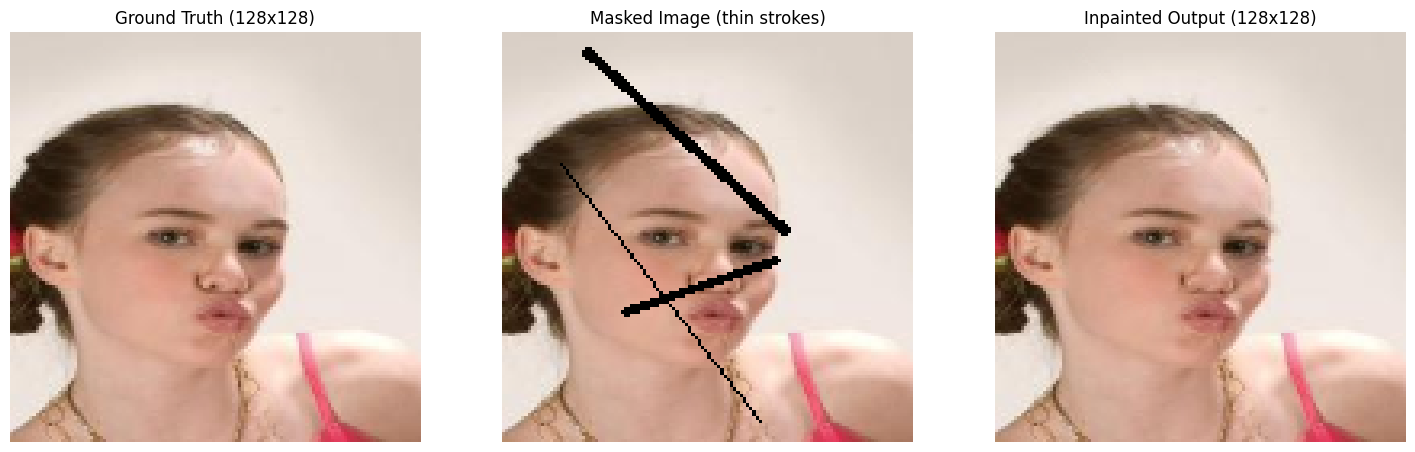

PSNR: 39.20 dB
SSIM: 0.9941


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# Step 1: Load and resize image
# ==============================
img_path = "/Users/shreyagupta/Desktop/img_align_celeba/000086.jpg"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found at: {img_path}")

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (128, 128))   # resize to 128x128
h, w, _ = image.shape
print(f"Loaded image with shape: {image.shape}")

# ==============================
# Step 2: Generate irregular mask (2–3 thin strokes)
# ==============================
def generate_irregular_mask(height, width, min_strokes=2, max_strokes=3):
    mask = np.zeros((height, width), dtype=np.uint8)
    num_strokes = np.random.randint(min_strokes, max_strokes+1)
    for _ in range(num_strokes):
        x1, y1 = np.random.randint(0, width), np.random.randint(0, height)
        x2, y2 = np.random.randint(0, width), np.random.randint(0, height)
        thickness = np.random.randint(1, 3)  # thin lines
        cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)
    return mask

mask = generate_irregular_mask(h, w)

# ==============================
# Step 3: Apply mask to image (black-out regions)
# ==============================
masked_img = image.copy()
masked_img[mask==255] = 0

# ==============================
# Step 4: Inpainting (OpenCV demo)
# ==============================
inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

# ==============================
# Step 5: Display results (same style as 64x64)
# ==============================
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Ground Truth (128x128)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img)
plt.title("Masked Image (thin strokes)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(inpainted)
plt.title("Inpainted Output (128x128)")
plt.axis("off")

plt.show()

# ==============================
# Step 6: PSNR & SSIM
# ==============================
def compute_ssim(img1, img2):
    """Compute SSIM for two RGB images (manual version, no skimage)."""
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    K1, K2 = 0.01, 0.03
    L = 255
    C1 = (K1 * L) ** 2
    C2 = (K2 * L) ** 2

    ssim_total = 0
    for ch in range(3):  # per-channel SSIM
        x = img1[:,:,ch]
        y = img2[:,:,ch]

        mu_x = cv2.GaussianBlur(x, (11,11), 1.5)
        mu_y = cv2.GaussianBlur(y, (11,11), 1.5)

        mu_x_sq = mu_x * mu_x
        mu_y_sq = mu_y * mu_y
        mu_xy = mu_x * mu_y

        sigma_x_sq = cv2.GaussianBlur(x*x, (11,11), 1.5) - mu_x_sq
        sigma_y_sq = cv2.GaussianBlur(y*y, (11,11), 1.5) - mu_y_sq
        sigma_xy   = cv2.GaussianBlur(x*y, (11,11), 1.5) - mu_xy

        ssim_map = ((2*mu_xy + C1) * (2*sigma_xy + C2)) / \
                   ((mu_x_sq + mu_y_sq + C1) * (sigma_x_sq + sigma_y_sq + C2))

        ssim_total += ssim_map.mean()

    return ssim_total / 3

# Compute metrics
psnr_value = cv2.PSNR(image, inpainted)
ssim_value = compute_ssim(image, inpainted)

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.4f}")


Loaded image with shape: (256, 256, 3)


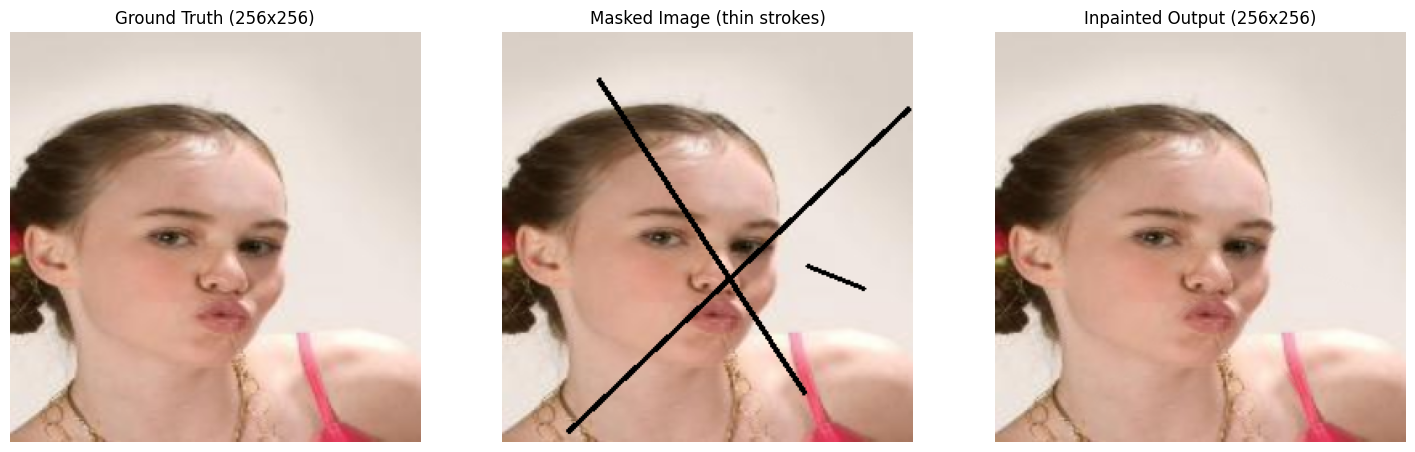

PSNR: 47.64 dB
SSIM: 0.9974


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ==============================
# Step 1: Load and resize image
# ==============================
img_path = "/Users/shreyagupta/Desktop/img_align_celeba/000086.jpg"

if not os.path.exists(img_path):
    raise FileNotFoundError(f"Image not found at: {img_path}")

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (256, 256))   # resize to 256x256
h, w, _ = image.shape
print(f"Loaded image with shape: {image.shape}")

# ==============================
# Step 2: Generate irregular mask (2–3 thin strokes)
# ==============================
def generate_irregular_mask(height, width, min_strokes=2, max_strokes=3):
    mask = np.zeros((height, width), dtype=np.uint8)
    num_strokes = np.random.randint(min_strokes, max_strokes+1)
    for _ in range(num_strokes):
        x1, y1 = np.random.randint(0, width), np.random.randint(0, height)
        x2, y2 = np.random.randint(0, width), np.random.randint(0, height)
        thickness = np.random.randint(1, 3)  # thin lines
        cv2.line(mask, (x1, y1), (x2, y2), 255, thickness)
    return mask

mask = generate_irregular_mask(h, w)

# ==============================
# Step 3: Apply mask to image (black-out regions)
# ==============================
masked_img = image.copy()
masked_img[mask==255] = 0

# ==============================
# Step 4: Inpainting (OpenCV demo)
# ==============================
inpainted = cv2.inpaint(image, mask, 3, cv2.INPAINT_TELEA)

# ==============================
# Step 5: Display results (like before)
# ==============================
plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.imshow(image)
plt.title("Ground Truth (256x256)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(masked_img)
plt.title("Masked Image (thin strokes)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(inpainted)
plt.title("Inpainted Output (256x256)")
plt.axis("off")

plt.show()

# ==============================
# Step 6: PSNR & SSIM
# ==============================
def compute_ssim(img1, img2):
    """Compute SSIM for two RGB images (manual version, no skimage)."""
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    K1, K2 = 0.01, 0.03
    L = 255
    C1 = (K1 * L) ** 2
    C2 = (K2 * L) ** 2

    ssim_total = 0
    for ch in range(3):  # per-channel SSIM
        x = img1[:,:,ch]
        y = img2[:,:,ch]

        mu_x = cv2.GaussianBlur(x, (11,11), 1.5)
        mu_y = cv2.GaussianBlur(y, (11,11), 1.5)

        mu_x_sq = mu_x * mu_x
        mu_y_sq = mu_y * mu_y
        mu_xy = mu_x * mu_y

        sigma_x_sq = cv2.GaussianBlur(x*x, (11,11), 1.5) - mu_x_sq
        sigma_y_sq = cv2.GaussianBlur(y*y, (11,11), 1.5) - mu_y_sq
        sigma_xy   = cv2.GaussianBlur(x*y, (11,11), 1.5) - mu_xy

        ssim_map = ((2*mu_xy + C1) * (2*sigma_xy + C2)) / \
                   ((mu_x_sq + mu_y_sq + C1) * (sigma_x_sq + sigma_y_sq + C2))

        ssim_total += ssim_map.mean()

    return ssim_total / 3

# Compute metrics
psnr_value = cv2.PSNR(image, inpainted)
ssim_value = compute_ssim(image, inpainted)

print(f"PSNR: {psnr_value:.2f} dB")
print(f"SSIM: {ssim_value:.4f}")
